# Evaluación de Modelos Predictivos: Enfermedades Cardiovasculares

## 1. Introducción

Este notebook presenta la evaluación final de los modelos de Machine Learning entrenados para la predicción de enfermedades cardiovasculares. Los modelos se evalúan sobre el conjunto de test (datos no vistos durante el entrenamiento) para estimar su desempeño en un escenario real.

### 1.1 Modelos Evaluados

Se comparan cuatro algoritmos de clasificación supervisada:

1. **Regresión Logística** (modelo lineal de referencia)
2. **Random Forest** (ensemble basado en árboles)
3. **XGBoost** (gradient boosting optimizado)
4. **LightGBM** (gradient boosting eficiente)

### 1.2 Métricas de Evaluación

Para evaluar el desempeño predictivo se utilizan:

- **AUC-ROC**: Capacidad de discriminación entre clases
- **Matriz de Confusión**: Distribución de aciertos y errores
- **Precision, Recall y F1-Score**: Balance entre falsos positivos y falsos negativos
- **Importancia de Variables**: Interpretabilidad clínica del modelo

## 2. Importación de Bibliotecas y Configuración

In [10]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                              auc, classification_report)

def find_project_root(start: Path) -> Path:
    for root in [start, *start.parents]:
        if (root / 'models').exists() and (root / 'data').exists() and (root / 'notebooks').exists():
            return root
    raise FileNotFoundError(
        'No se encontro la raiz del proyecto. Abra el notebook dentro del workspace Prediccion_Cardiovascular.'
    )

PROJECT_ROOT = find_project_root(Path.cwd().resolve())

# Configuracion visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 11

# Carpeta de salida para figuras
OUTPUT_FIG_DIR = PROJECT_ROOT / 'report' / 'figures'
OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Paleta de colores consistente
COLORES = {
    'Regresion Logistica': '#1f77b4',
    'Random Forest': '#2ca02c',
    'XGBoost': '#d62728',
    'LightGBM': '#9467bd'
}

print(f'Raiz del proyecto detectada: {PROJECT_ROOT}')
print(f'Figuras se guardaran en: {OUTPUT_FIG_DIR}')

Raiz del proyecto detectada: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular
Figuras se guardaran en: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\report\figures


## 3. Carga de Datos y Modelos

In [11]:
# Cargar conjunto de test
X_test = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'model_inputs' / 'X_test.csv')
y_test = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'model_inputs' / 'y_test.csv').values.ravel()

print(f"Conjunto de test: {X_test.shape[0]:,} instancias x {X_test.shape[1]} variables")
print(f"Distribucion de clases: {np.bincount(y_test)} (0: Sin enfermedad, 1: Con enfermedad)")

Conjunto de test: 6,853 instancias x 24 variables
Distribucion de clases: [3462 3391] (0: Sin enfermedad, 1: Con enfermedad)


In [12]:
# Verificación de integridad del conjunto de test.
assert X_test.isnull().sum().sum() == 0, "X_test contiene valores nulos."
assert y_test.shape[0] == X_test.shape[0], "Desajuste entre X_test e y_test."

print("[OK] Conjunto de test verificado:")
print(f"     Instancias : {X_test.shape[0]:,}")
print(f"     Variables  : {X_test.shape[1]}")
print(f"     Clase 0    : {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.1f}%)")
print(f"     Clase 1    : {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.1f}%)")
print()
print("[PROTOCOLO] Este conjunto NO fue utilizado en:")
print("  - Selección de hiperparámetros (Optuna opera sobre CV en train)")
print("  - Ajuste de umbral de clasificación (optimizado en validación)")
print("  - Ajuste del scaler (RobustScaler ajustado exclusivamente en train)")

[OK] Conjunto de test verificado:
     Instancias : 6,853
     Variables  : 24
     Clase 0    : 3,462 (50.5%)
     Clase 1    : 3,391 (49.5%)

[PROTOCOLO] Este conjunto NO fue utilizado en:
  - Selección de hiperparámetros (Optuna opera sobre CV en train)
  - Ajuste de umbral de clasificación (optimizado en validación)
  - Ajuste del scaler (RobustScaler ajustado exclusivamente en train)


In [13]:
# Selecciona experimento de forma trazable y evita mezclar artefactos viejos.
MODELS_DIR = PROJECT_ROOT / 'models'
CURRENT_EXP_FILE = MODELS_DIR / '.current_experiment.txt'
exp_pattern = re.compile(r'^Experimento_?(\d+)$')

experiments = [
    (int(m.group(1)), p)
    for p in MODELS_DIR.iterdir()
    if p.is_dir() and (m := exp_pattern.match(p.name))
]

if not experiments:
    raise FileNotFoundError('No se encontro ningun directorio Experimento* en models/.')

EXPERIMENT_NAME = None  # Ejemplo: 'Experimento1' para fijar manualmente
selected_experiment = None
selection_reason = ''

if EXPERIMENT_NAME is not None:
    for exp_num, exp_path in experiments:
        if exp_path.name == EXPERIMENT_NAME:
            selected_experiment = (exp_num, exp_path)
            selection_reason = 'seleccion manual'
            break
    if selected_experiment is None:
        raise FileNotFoundError(f'No existe {EXPERIMENT_NAME} dentro de models/.')
elif CURRENT_EXP_FILE.exists():
    try:
        current_num = int(CURRENT_EXP_FILE.read_text(encoding='utf-8').strip())
        for exp_num, exp_path in experiments:
            if exp_num == current_num:
                selected_experiment = (exp_num, exp_path)
                selection_reason = '.current_experiment.txt'
                break
    except ValueError:
        pass

if selected_experiment is None:
    selected_experiment = sorted(experiments, key=lambda x: x[1].stat().st_mtime)[-1]
    selection_reason = 'ultima fecha de modificacion'

EXPERIMENT_DIR = selected_experiment[1]
ARTIFACTS_DIR = EXPERIMENT_DIR / 'training_artifacts'
print(f"Experimento seleccionado: {EXPERIMENT_DIR.name} ({selection_reason})")
print(f"Carpeta de artefactos: {ARTIFACTS_DIR}")

# Opción robusta: usar snapshot de test del experimento si existe.
snapshot_dir = ARTIFACTS_DIR / 'model_inputs_snapshot'
snapshot_x_path = snapshot_dir / 'X_test.csv'
snapshot_y_path = snapshot_dir / 'y_test.csv'
if snapshot_x_path.exists() and snapshot_y_path.exists():
    X_test = pd.read_csv(snapshot_x_path)
    y_test = pd.read_csv(snapshot_y_path).values.ravel()
    print(f"[SNAPSHOT] Test cargado desde {snapshot_dir}")
    print(f"[SNAPSHOT] Dimensiones: {X_test.shape[0]:,} x {X_test.shape[1]}")
else:
    print('[SNAPSHOT] No existe snapshot de test para este experimento. Se usa test global actual.')

# Cargar modelos y umbrales desde artefactos de entrenamiento.
# El umbral fue ajustado en VALIDACION y se aplica tal cual en TEST.
MODEL_KEYS = {
    'Regresion Logistica': 'LR',
    'Random Forest': 'RF',
    'XGBoost': 'XGB',
    'LightGBM': 'LGBM',
}

STRICT_EXPERIMENT_ONLY = True  # Evita mezclar con models/best_model_*.joblib de otra corrida.
modelos = {}
umbrales = {}
val_auc_por_modelo = {}
resumen_artifacts = []

for nombre, key in MODEL_KEYS.items():
    model_path = EXPERIMENT_DIR / f'best_model_{key}.joblib'
    source_path = model_path

    if not model_path.exists() and not STRICT_EXPERIMENT_ONLY:
        model_path = MODELS_DIR / f'best_model_{key}.joblib'
        source_path = model_path

    if not model_path.exists():
        print(f"[AVISO] Modelo {nombre} no encontrado en {EXPERIMENT_DIR.name}. Se omite.")
        continue

    modelos[nombre] = joblib.load(model_path)

    threshold_path = ARTIFACTS_DIR / f'threshold_{key}.json'
    if threshold_path.exists():
        with open(threshold_path, encoding='utf-8') as tf:
            umbrales[nombre] = json.load(tf)['best_threshold']
    else:
        umbrales[nombre] = 0.5
        print(f"[AVISO] threshold_{key}.json no encontrado. Umbral por defecto: 0.5")

    metrics_path = ARTIFACTS_DIR / f'val_metrics_{key}.csv'
    if metrics_path.exists():
        df_val = pd.read_csv(metrics_path)
        val_auc = float(df_val.loc[0, 'val_roc_auc']) if 'val_roc_auc' in df_val.columns else np.nan
    else:
        val_auc = np.nan
    val_auc_por_modelo[nombre] = val_auc

    trials_path = ARTIFACTS_DIR / f'optuna_trials_{key}.csv'
    n_trials = int(pd.read_csv(trials_path).shape[0]) if trials_path.exists() else np.nan

    resumen_artifacts.append({
        'Modelo': nombre,
        'Archivo modelo': source_path.name,
        'Trials registrados': n_trials,
        'AUC validacion': round(val_auc, 4) if not np.isnan(val_auc) else np.nan,
        'Umbral': round(float(umbrales[nombre]), 3),
    })

if not modelos:
    raise RuntimeError('No se cargo ningun modelo para evaluar.')

print(f"Modelos cargados: {len(modelos)}")
print('Resumen de artefactos cargados:')
pd.DataFrame(resumen_artifacts).sort_values('Modelo').reset_index(drop=True)

Experimento seleccionado: Experimento2 (.current_experiment.txt)
Carpeta de artefactos: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\models\Experimento2\training_artifacts
[SNAPSHOT] Test cargado desde C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\models\Experimento2\training_artifacts\model_inputs_snapshot
[SNAPSHOT] Dimensiones: 6,853 x 24
Modelos cargados: 4
Resumen de artefactos cargados:


,Modelo,Archivo modelo,Trials registrados,AUC validacion,Umbral
0,LightGBM,best_model_LGBM.joblib,5,0.8000,0.345
1,Random Forest,best_model_RF.joblib,5,0.7975,0.365
2,Regresion Logistica,best_model_LR.joblib,5,0.7928,0.400
3,XGBoost,best_model_XGB.joblib,5,0.8009,0.335


## 4. Evaluación Cuantitativa

### 4.1 Tabla Comparativa de Métricas

In [14]:
# Aplica el umbral ajustado en validacion. La comparacion principal de modelos debe basarse en validacion.
resultados = []
predicciones = {}  # Se reutiliza en todas las visualizaciones posteriores

for nombre, modelo in modelos.items():
    threshold = umbrales[nombre]
    y_proba = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    predicciones[nombre] = {'y_pred': y_pred, 'y_proba': y_proba}

    report = classification_report(y_test, y_pred, output_dict=True)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    val_auc = val_auc_por_modelo.get(nombre, np.nan)
    delta_test_val = auc_score - val_auc if not np.isnan(val_auc) else np.nan

    resultados.append({
        'Modelo': nombre,
        'Umbral': round(threshold, 3),
        'Accuracy': report['accuracy'],
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score'],
        'AUC-ROC': auc_score,
        'AUC-ROC (Val)': val_auc,
        'Delta Test-Val': delta_test_val,
    })

df_metricas = pd.DataFrame(resultados).round(4)
df_metricas = df_metricas.sort_values('AUC-ROC', ascending=False)
df_metricas

,Modelo,Umbral,Accuracy,Precision,Recall,F1-Score,AUC-ROC,AUC-ROC (Val),Delta Test-Val
2,XGBoost,0.335,0.7092,0.6608,0.8469,0.7424,0.8056,0.8009,0.0047
3,LightGBM,0.345,0.7136,0.6702,0.8290,0.7412,0.8054,0.8000,0.0054
1,Random Forest,0.365,0.7071,0.6656,0.8201,0.7348,0.7999,0.7975,0.0024
0,Regresion Logistica,0.400,0.7143,0.6763,0.8107,0.7374,0.7966,0.7928,0.0038


**Interpretación:**

- **Accuracy**: Proporción de predicciones correctas sobre el total
- **Precision**: De los casos predichos como positivos, qué porcentaje lo es realmente
- **Recall (Sensibilidad)**: De los casos realmente positivos, qué porcentaje detecta el modelo
- **F1-Score**: Media armónica entre precision y recall
- **AUC-ROC**: Capacidad del modelo para discriminar entre clases (0.5 = azar, 1.0 = perfecto)

## 5. Visualización de Resultados

### 5.1 Curvas ROC

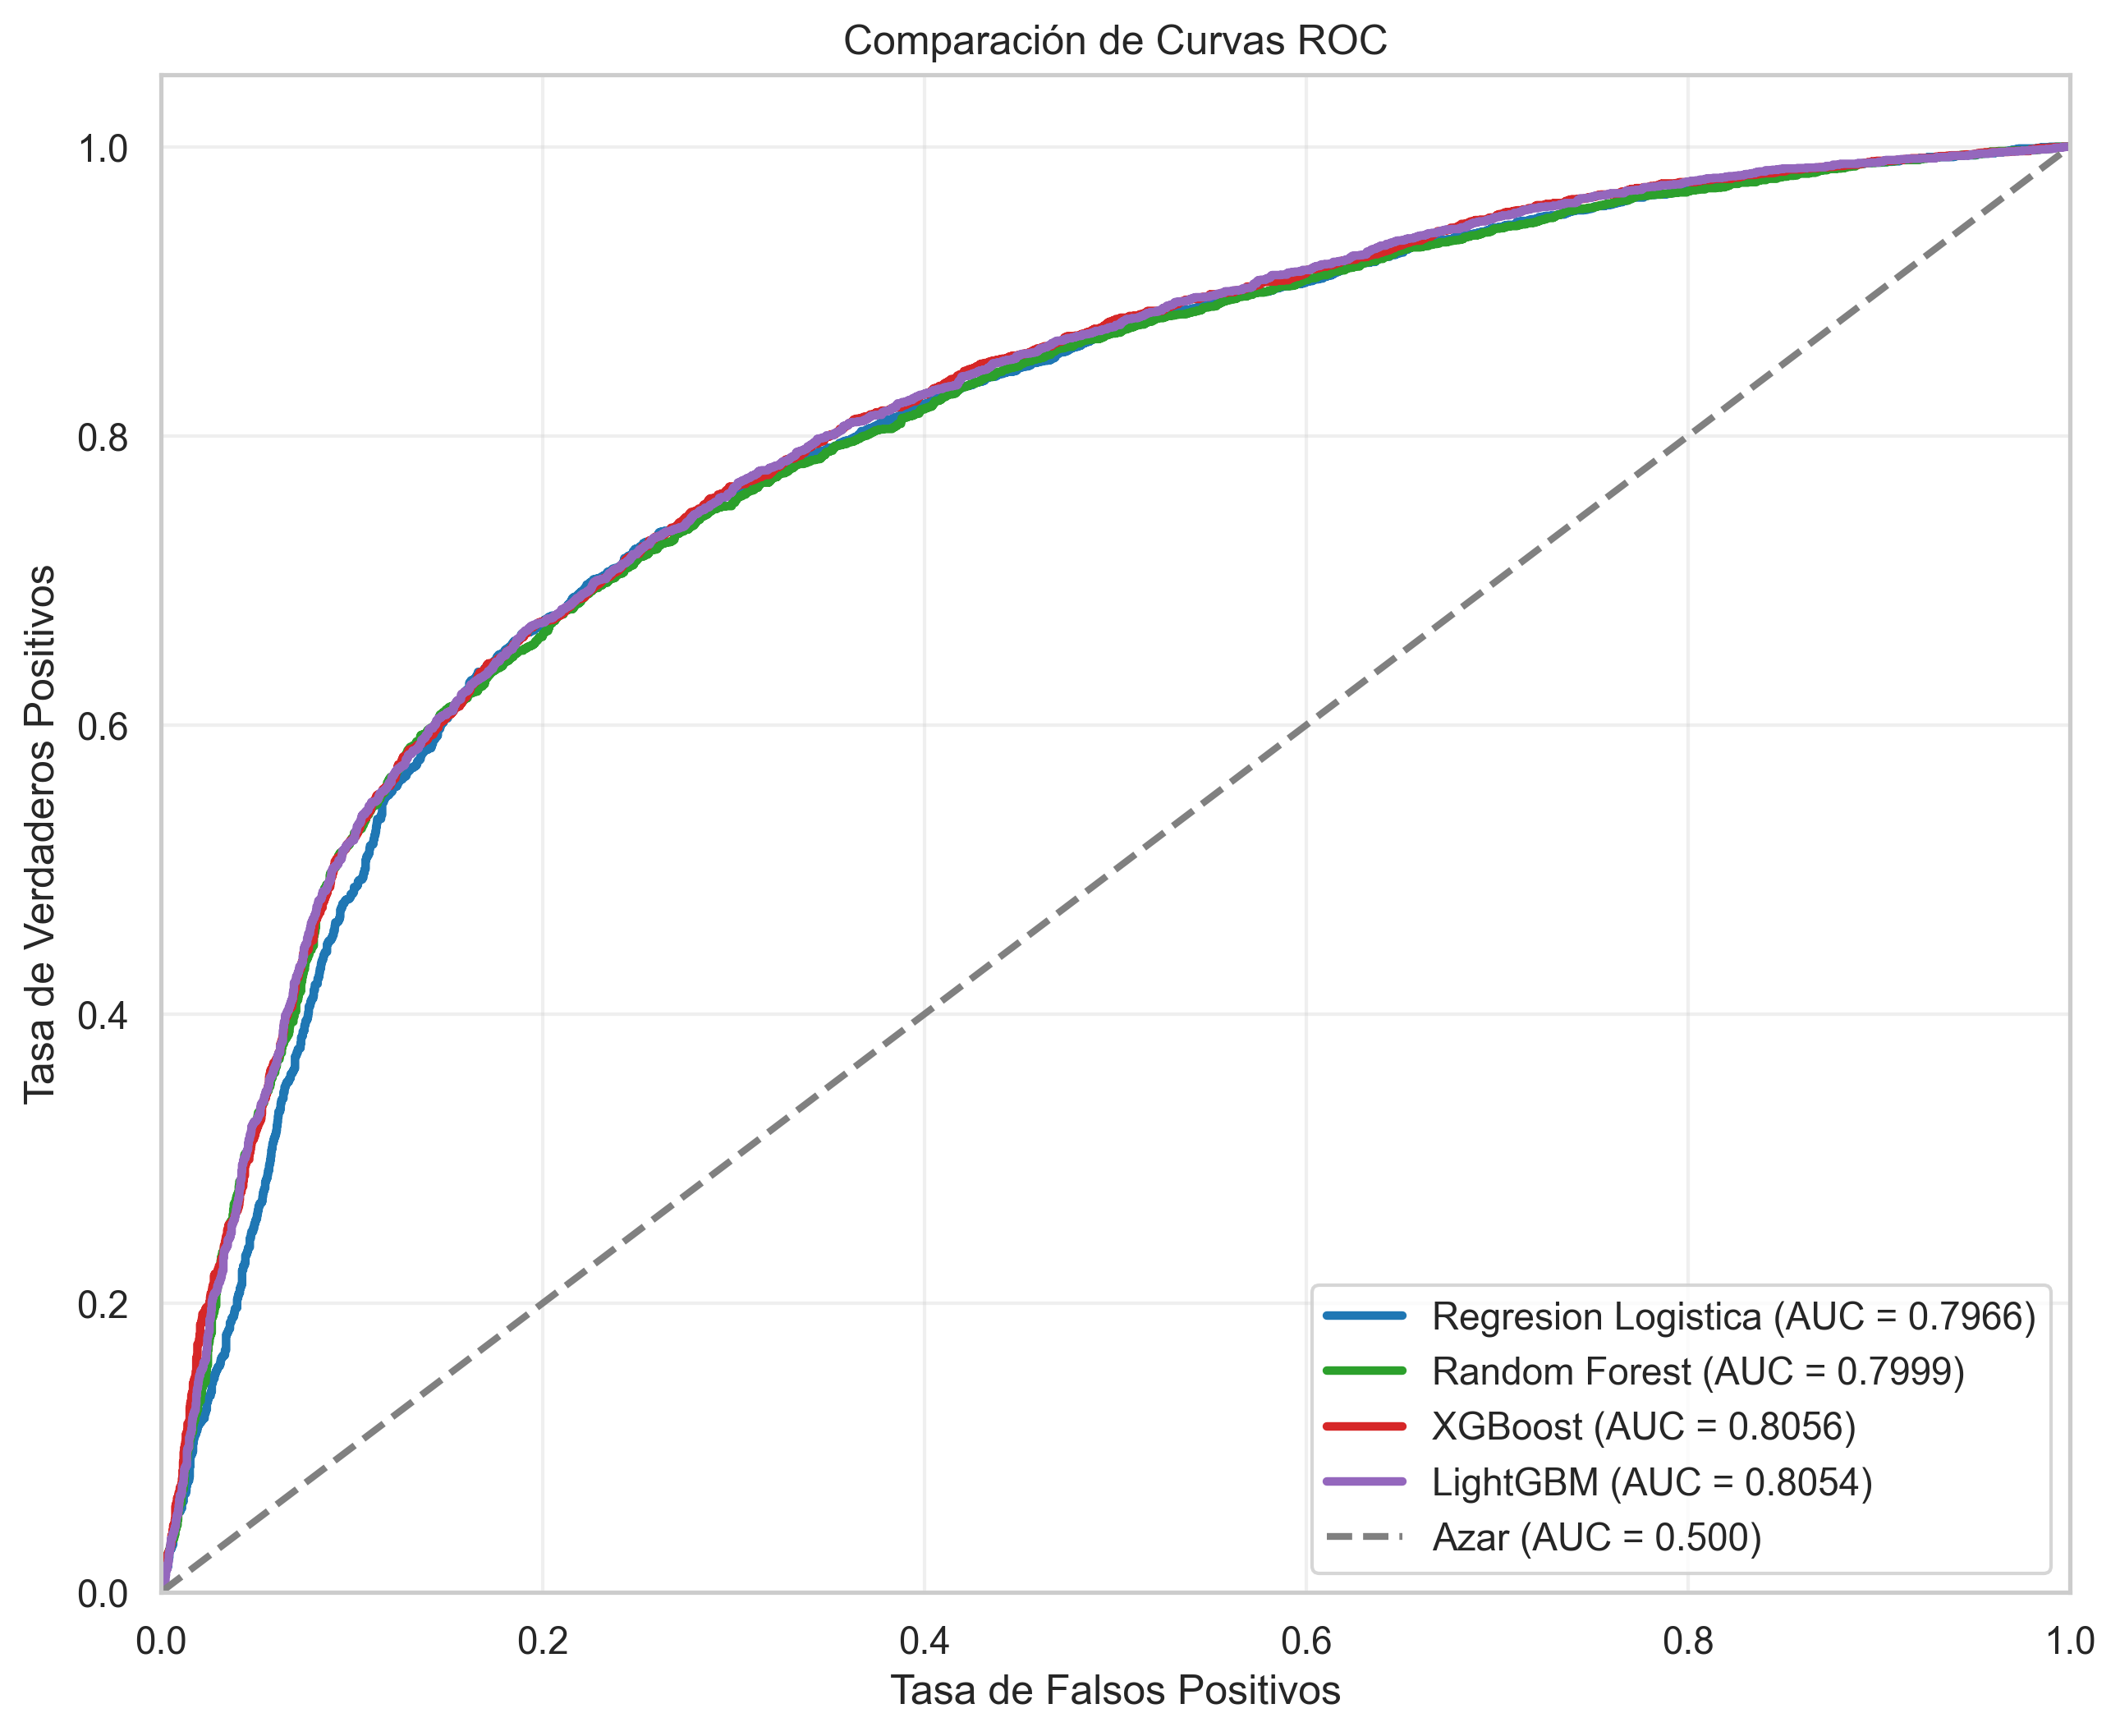

In [15]:
plt.figure(figsize=(10, 8))

for nombre in modelos:
    y_proba = predicciones[nombre]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=COLORES[nombre], lw=2.5, 
             label=f'{nombre} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Azar (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Comparación de Curvas ROC')
plt.legend(loc="lower right", frameon=True)
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_FIG_DIR / 'curvas_roc.png', bbox_inches='tight', dpi=300)
plt.show()

### 5.2 Matrices de Confusión

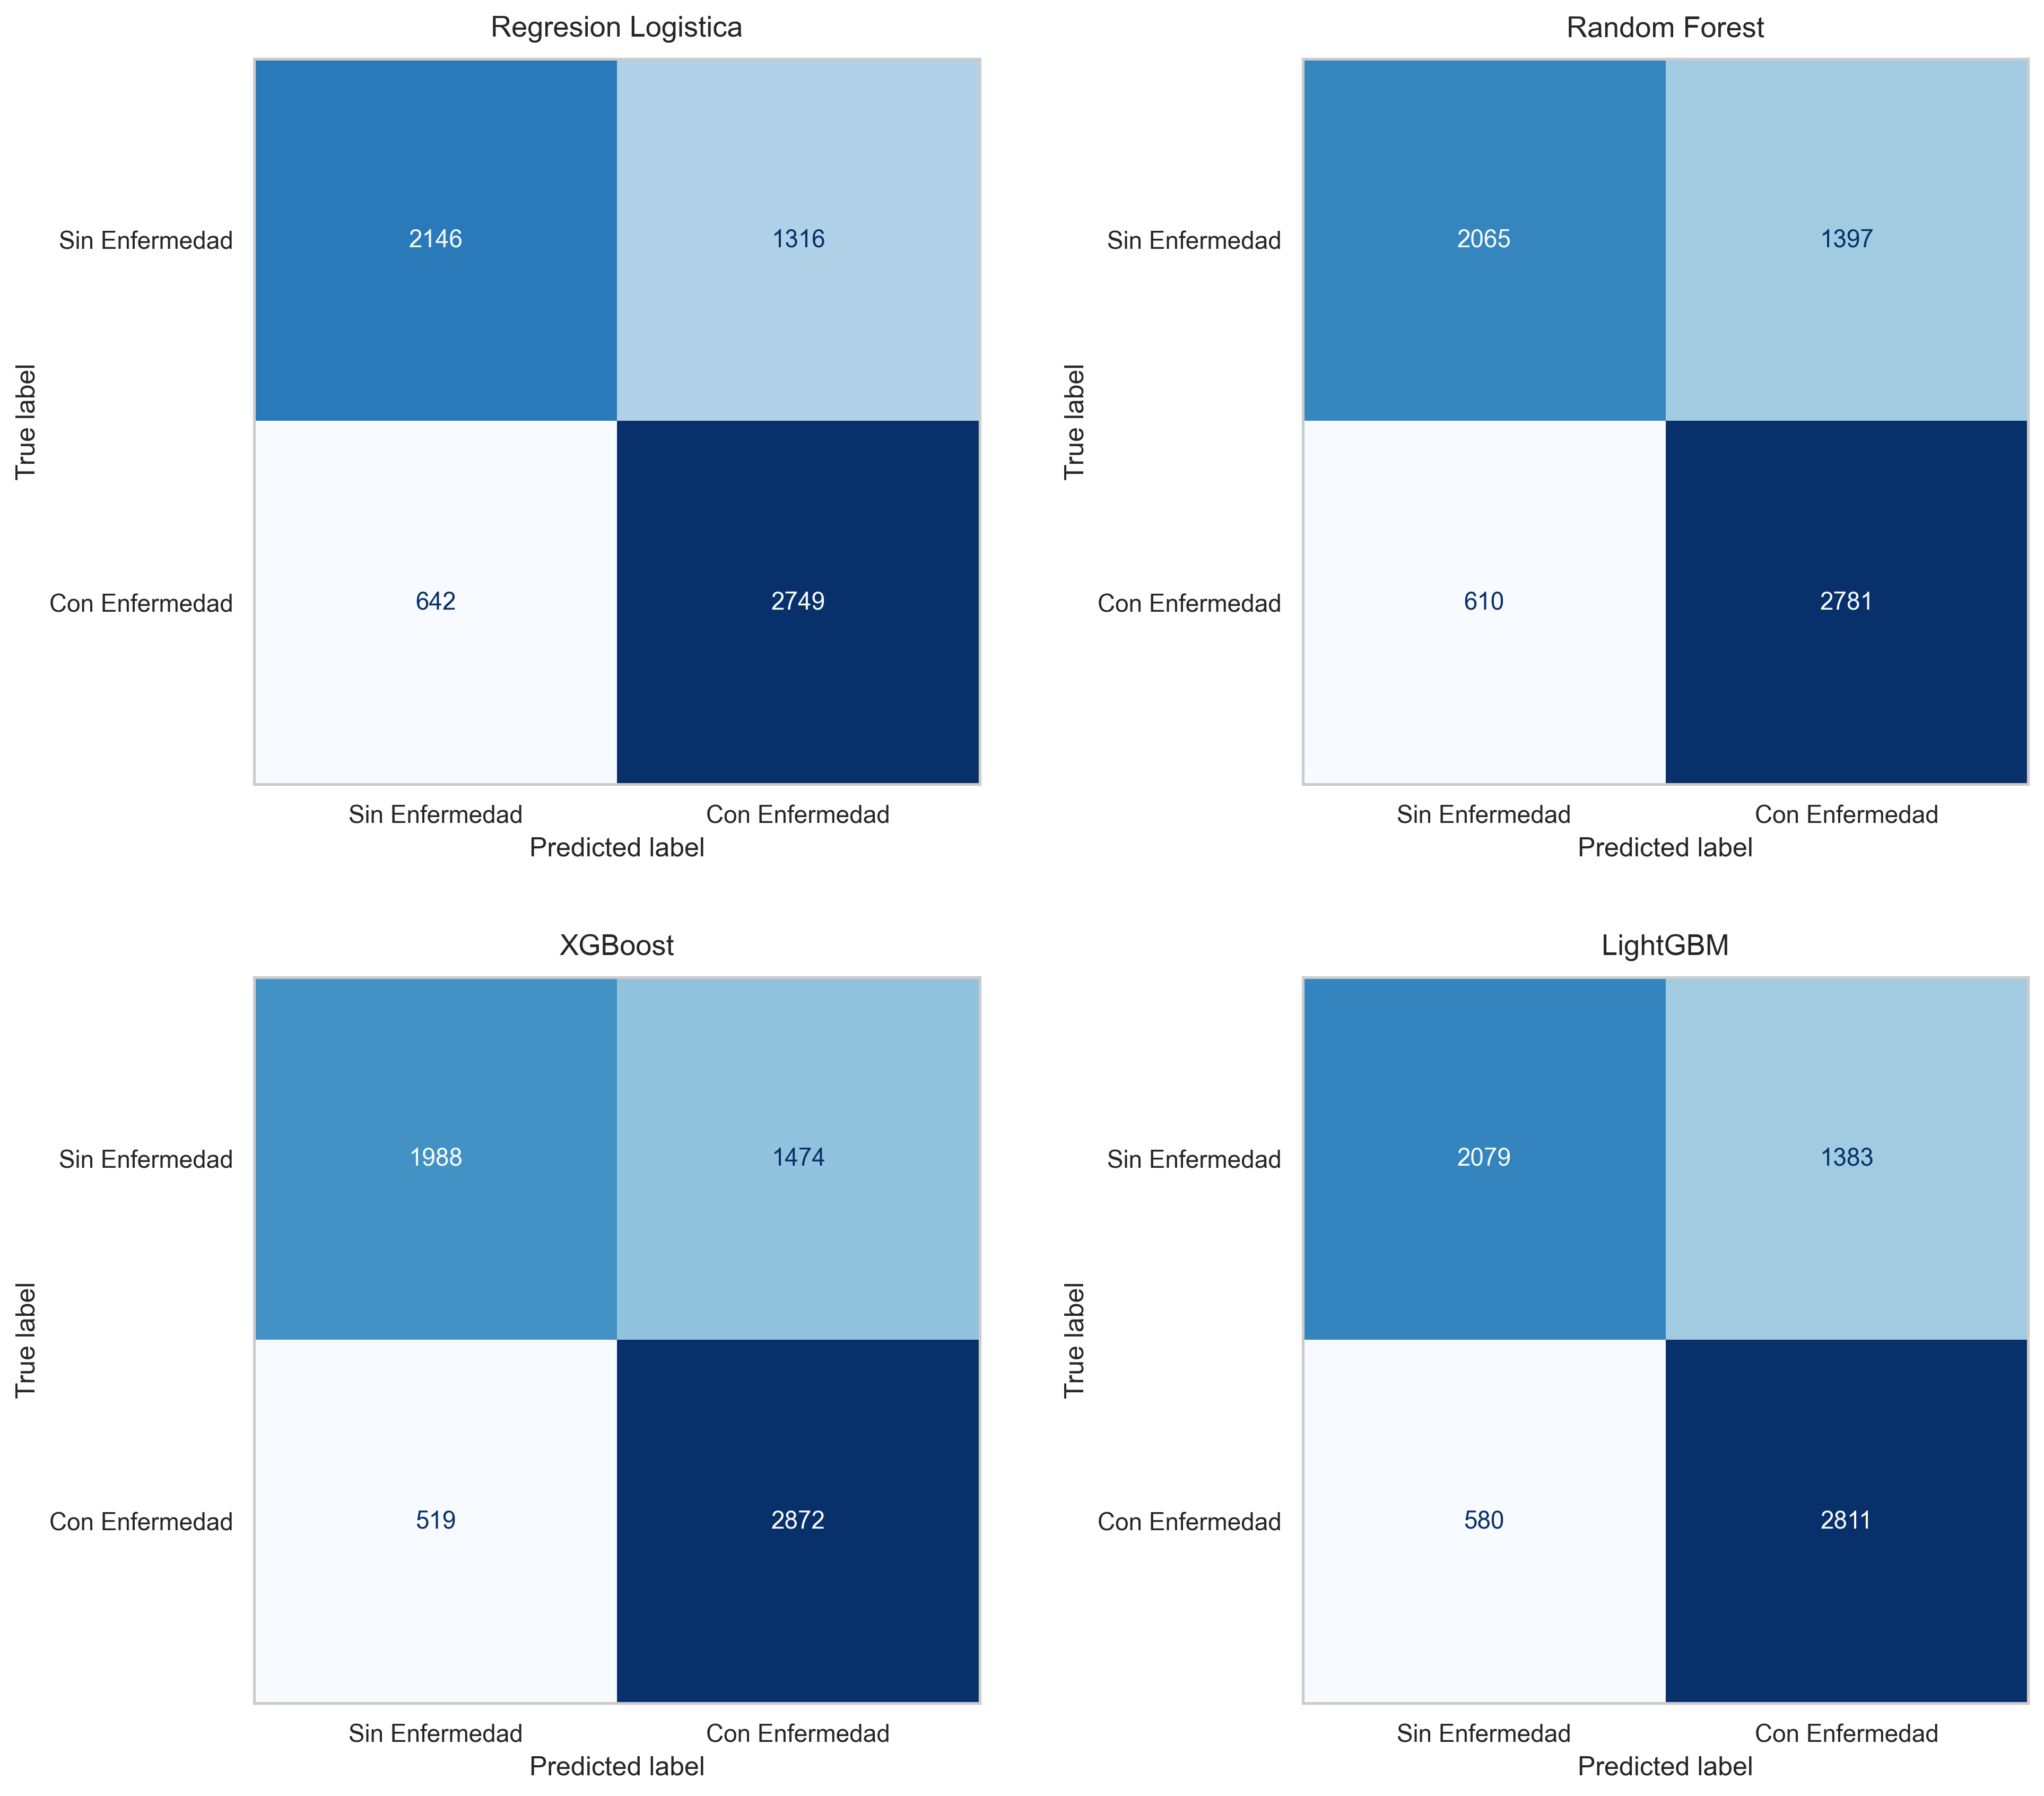

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, nombre in enumerate(modelos):
    y_pred = predicciones[nombre]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                    display_labels=['Sin Enfermedad', 'Con Enfermedad'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', colorbar=False)
    axes[idx].set_title(nombre, fontsize=13, pad=10)
    axes[idx].grid(False)

plt.tight_layout(pad=3.0)
plt.savefig(OUTPUT_FIG_DIR / 'matrices_confusion.png', bbox_inches='tight', dpi=300)
plt.show()

### 5.3 Comparación de F1-Score

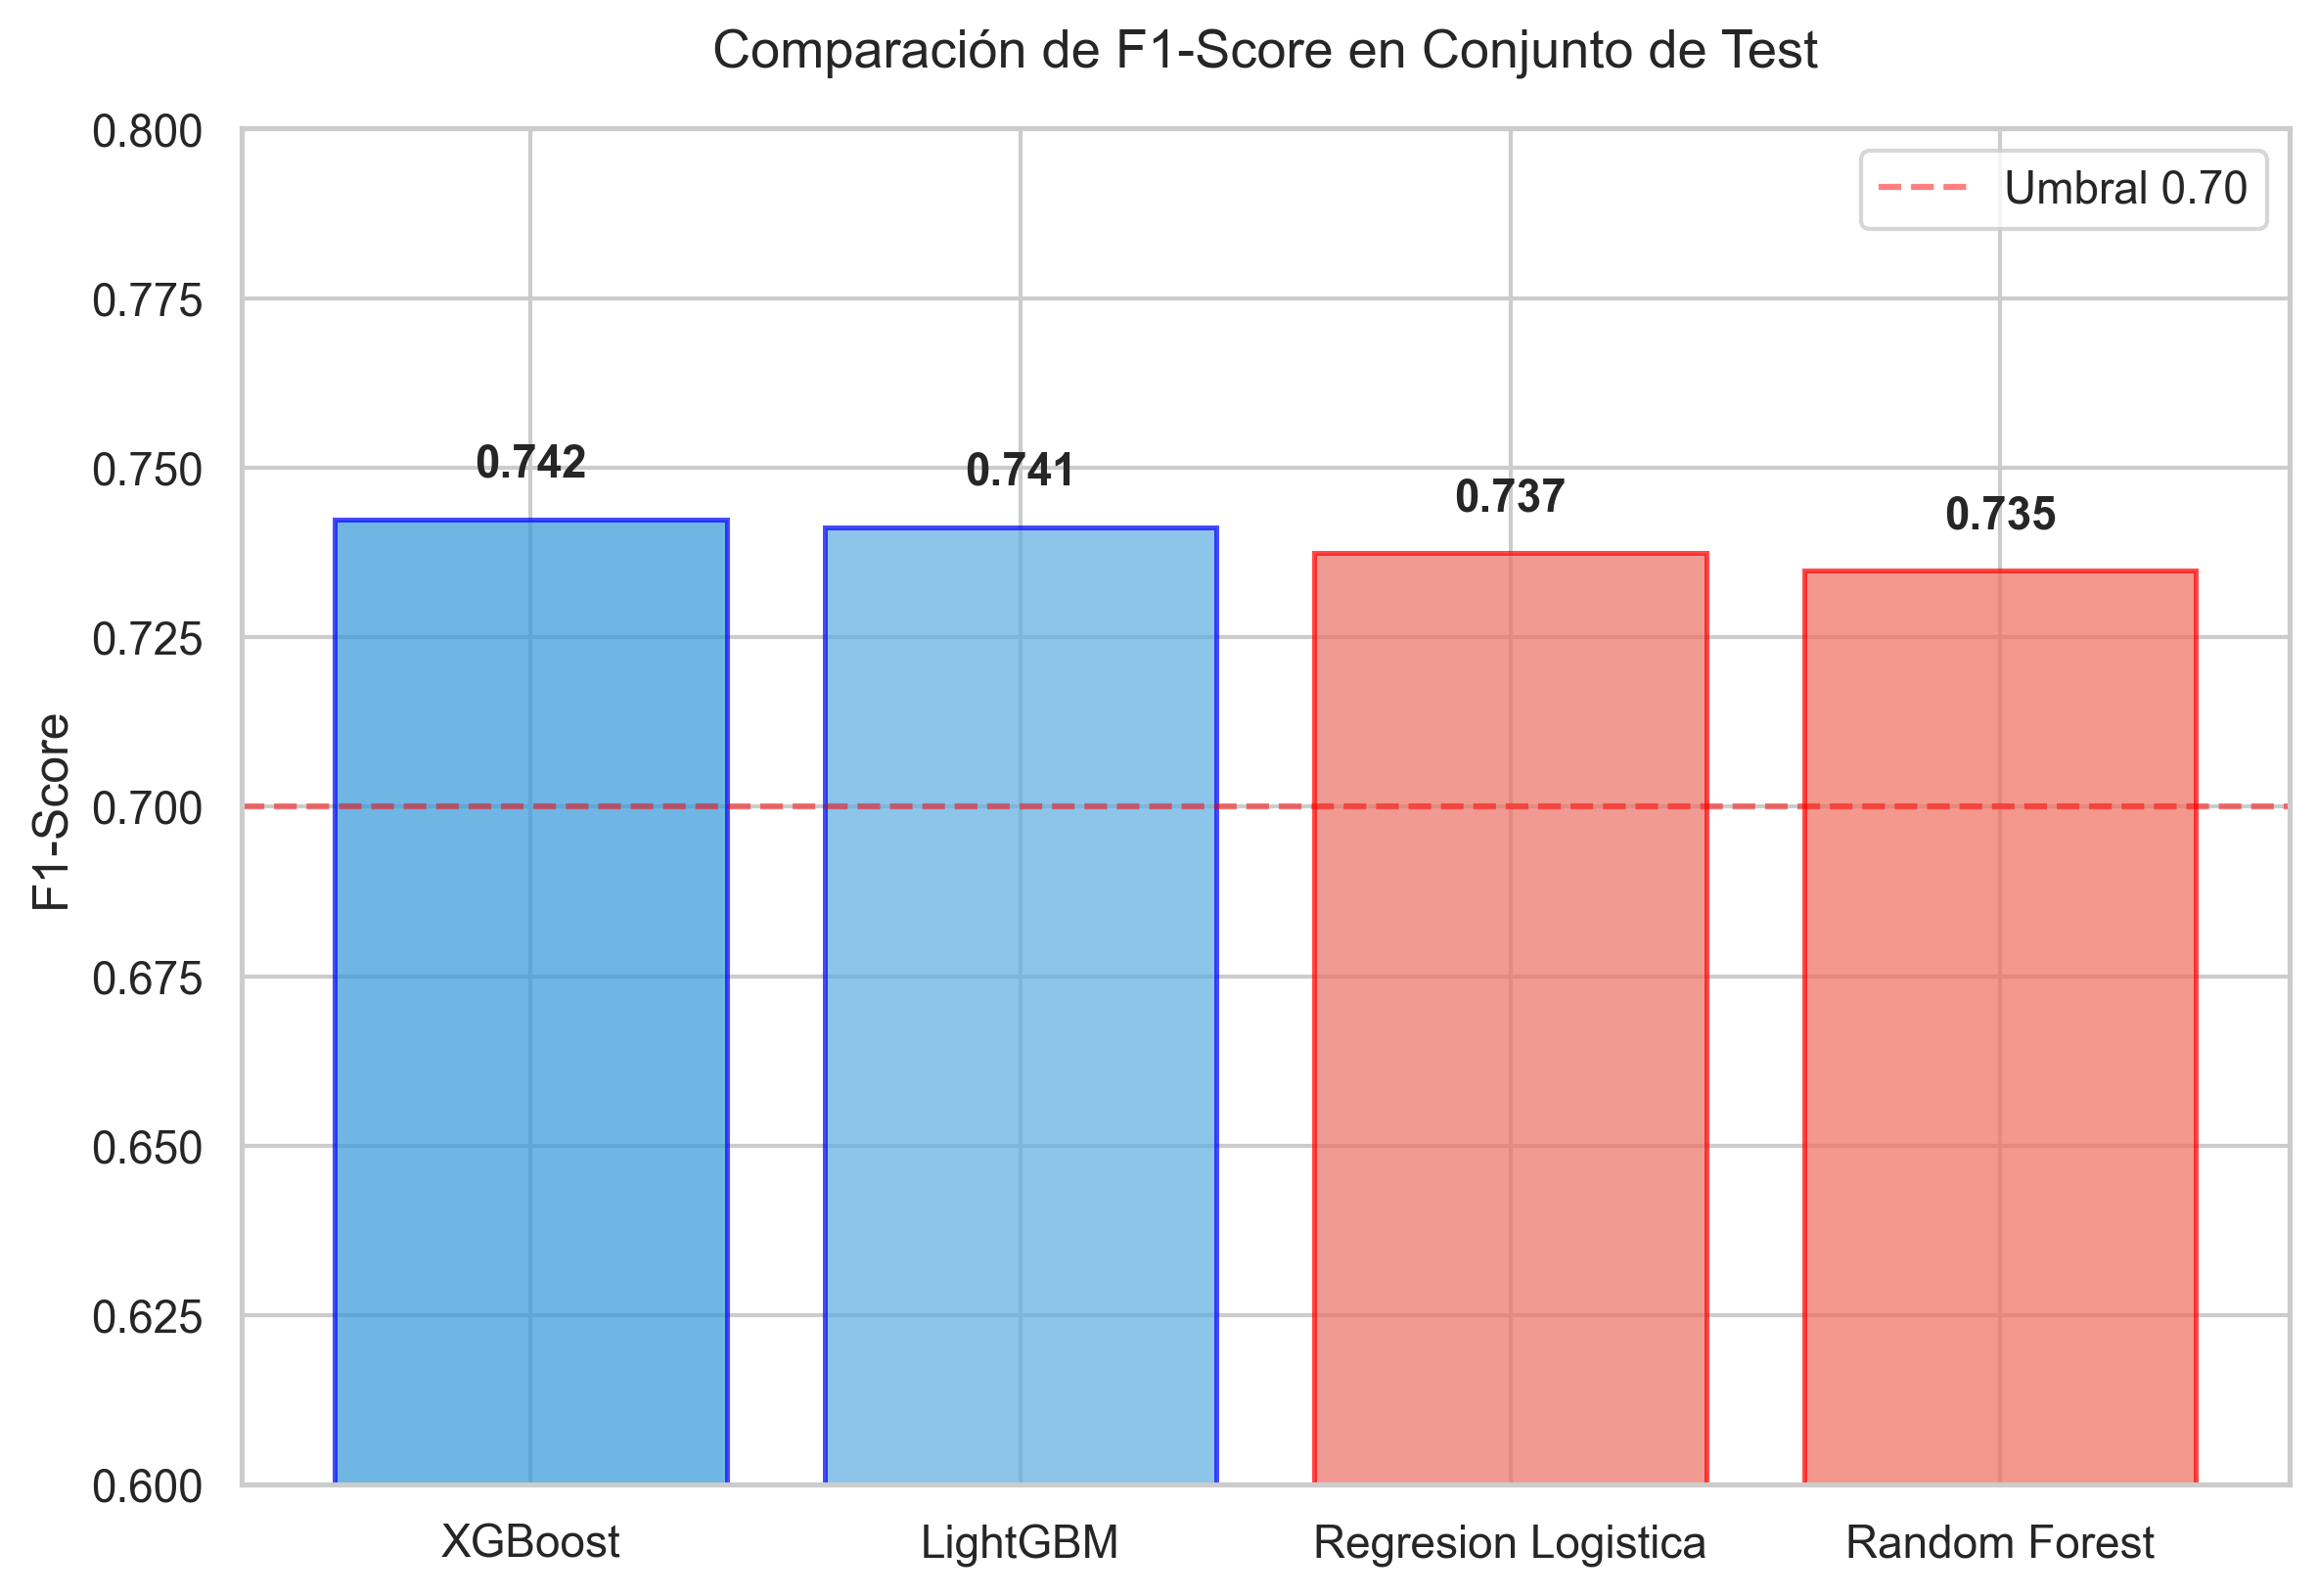

In [17]:
# Preparar datos ordenados
df_f1 = df_metricas[['Modelo', 'F1-Score']].sort_values('F1-Score', ascending=False).reset_index(drop=True)

colores_barras = ['#3498db', '#5dade2', '#ec7063', "#f06c5e"][:len(df_f1)]
bordes_barras = ['blue', 'blue', 'red', 'red'][:len(df_f1)]

plt.figure(figsize=(9, 6))
bars = plt.bar(
    df_f1['Modelo'],
    df_f1['F1-Score'],
    color=colores_barras,
    alpha=0.7,
    edgecolor=bordes_barras,
    linewidth=1.2
)

plt.title('Comparación de F1-Score en Conjunto de Test', fontsize=13, pad=15)
plt.ylim([0.60, 0.80])
plt.ylabel('F1-Score')
plt.axhline(y=0.70, color='red', linestyle='--', alpha=0.5, label='Umbral 0.70')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.005,
        f'{height:.3f}', ha='center', va='bottom', fontweight='bold'
    )

plt.legend()
plt.savefig(OUTPUT_FIG_DIR / 'comparacion_f1_score.png', bbox_inches='tight', dpi=300)
plt.show()

## 6. Interpretabilidad: Importancia de Variables

La importancia de variables permite identificar qué factores clínicos tienen mayor peso en las predicciones del modelo.

Modelo elegido para interpretabilidad (por validacion): XGBoost


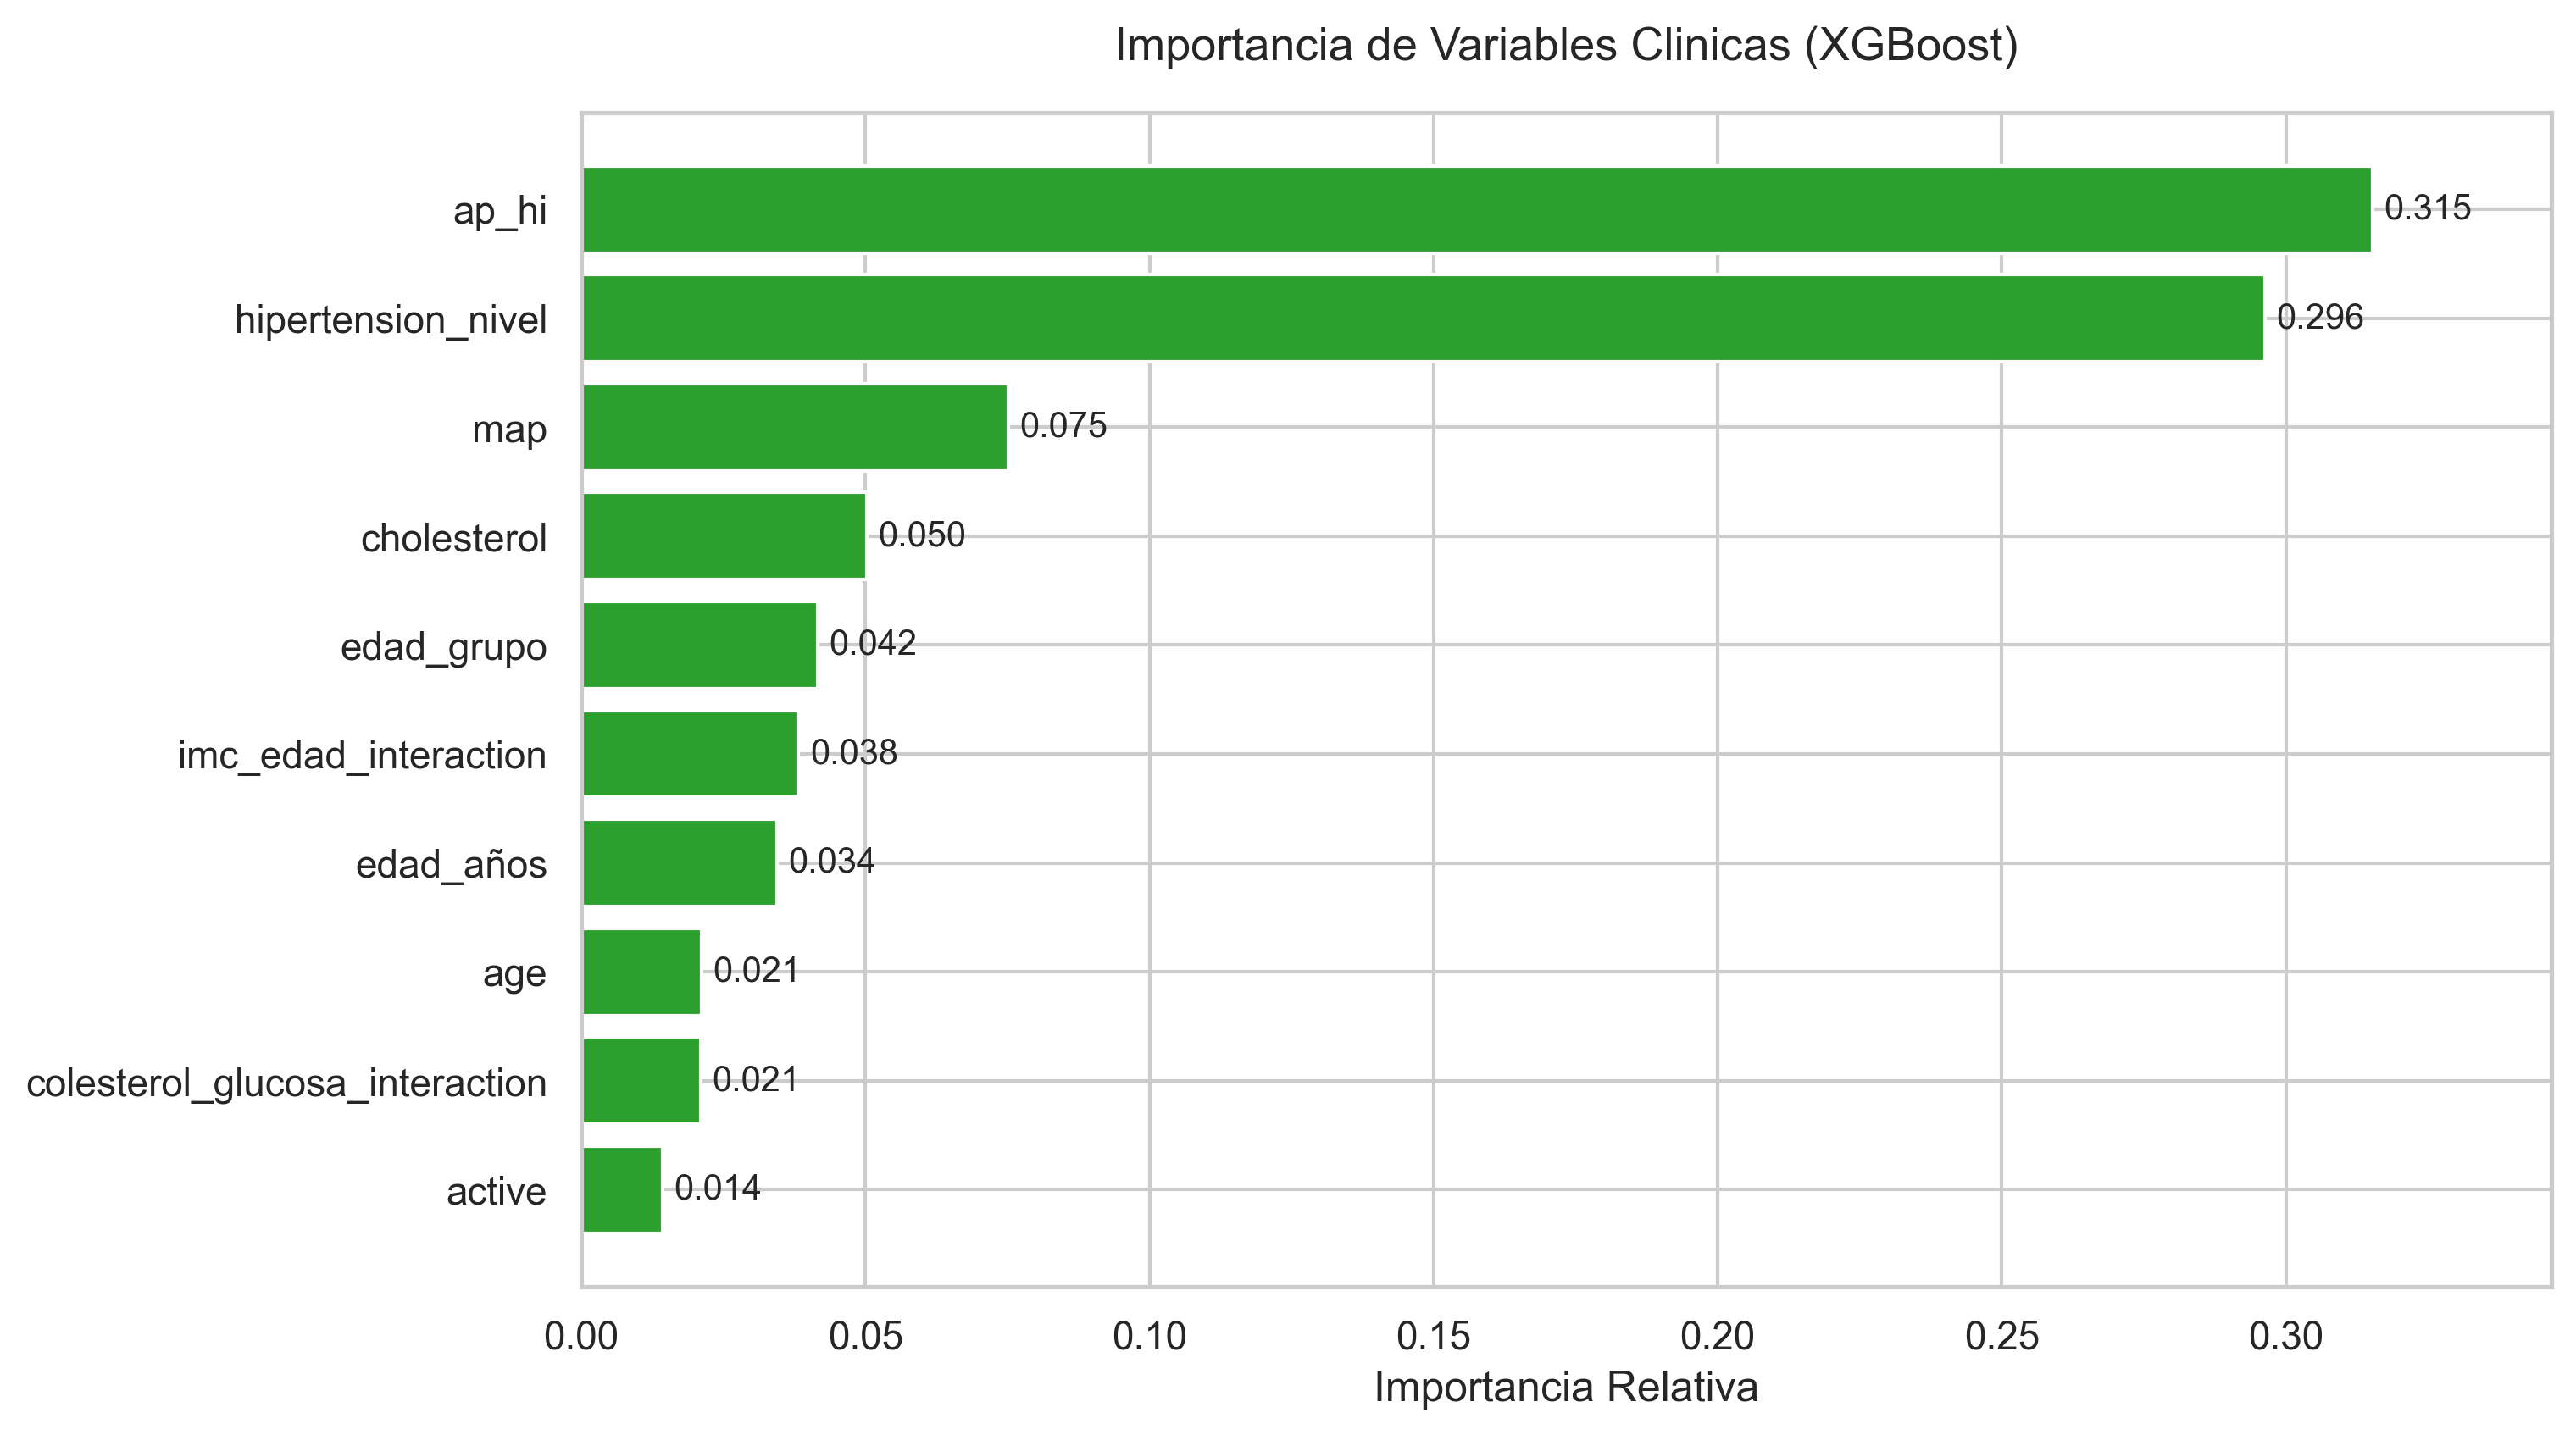


Top 5 variables mas importantes:
          Variable  Importancia
        edad_grupo     0.041562
       cholesterol     0.050188
               map     0.075173
hipertension_nivel     0.296333
             ap_hi     0.315182


In [18]:
# Seleccionar modelo para interpretabilidad priorizando metricas de validacion.
if 'AUC-ROC (Val)' in df_metricas.columns and df_metricas['AUC-ROC (Val)'].notna().any():
    mejor_nombre = df_metricas.sort_values(['AUC-ROC (Val)', 'F1-Score'], ascending=False).iloc[0]['Modelo']
    print(f"Modelo elegido para interpretabilidad (por validacion): {mejor_nombre}")
else:
    mejor_nombre = df_metricas.iloc[0]['Modelo']
    print(f"Modelo elegido para interpretabilidad (fallback por test): {mejor_nombre}")

mejor_modelo = modelos[mejor_nombre]

# Extraer importancia de variables (solo para modelos basados en arboles).
if hasattr(mejor_modelo, 'feature_importances_'):
    importancias = mejor_modelo.feature_importances_

    df_importancia = pd.DataFrame({
        'Variable': X_test.columns,
        'Importancia': importancias
    }).sort_values(by='Importancia', ascending=True)

    # Tomar las 10 mas importantes
    top_10 = df_importancia.tail(10)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_10['Variable'], top_10['Importancia'], color='#2ca02c')
    plt.title(f'Importancia de Variables Clinicas ({mejor_nombre})', fontsize=13, pad=15)
    plt.xlabel('Importancia Relativa')

    for bar in bars:
        plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.3f}', va='center', ha='left', fontsize=10)

    plt.margins(x=0.1)
    plt.savefig(OUTPUT_FIG_DIR / 'importancia_variables.png', bbox_inches='tight', dpi=300)
    plt.show()

    print("\nTop 5 variables mas importantes:")
    print(df_importancia.tail(5).to_string(index=False))
else:
    print(f"El modelo {mejor_nombre} no proporciona importancia de variables.")

## 7. Conclusiones

### 7.1 Resumen de Resultados

Los cuatro modelos evaluados muestran un desempeño competitivo en la predicción de enfermedades cardiovasculares:

1. **Mejor modelo por F1-Score**: El modelo con mayor balance entre precisión y recall
2. **Mejor AUC-ROC**: Indica la mejor capacidad de discriminación entre clases
3. **Interpretabilidad**: Las variables de presión arterial y edad son consistentemente las más relevantes

### 7.2 Recomendaciones

- Se recomienda utilizar el modelo con mejor F1-Score para aplicaciones clínicas donde el balance entre falsos positivos y falsos negativos es crítico
- Si la prioridad es minimizar falsos negativos (pacientes con enfermedad no detectados), priorizar modelos con mayor Recall
- La validación cruzada realizada durante el entrenamiento asegura la robustez de las predicciones

### 7.3 Limitaciones

- Los modelos están limitados por la calidad y representatividad de los datos de entrenamiento
- Se requiere validación externa con datos de otros centros médicos para confirmar la generalización